In [ ]:
import json, os

kaggle_username = ""   # replace with your actual Kaggle username
kaggle_key = ""               # replace with the key you got

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)

!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d faces_data

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:37<00:00, 108MB/s]



In [ ]:
import os

for root, dirs, filenames in os.walk("faces_data"):
    if filenames:
        print(root, "contains", len(filenames), "files")

faces_data contains 3 files
faces_data/real_vs_fake/real-vs-fake/valid/real contains 10000 files
faces_data/real_vs_fake/real-vs-fake/valid/fake contains 10000 files
faces_data/real_vs_fake/real-vs-fake/test/real contains 10000 files
faces_data/real_vs_fake/real-vs-fake/test/fake contains 10000 files
faces_data/real_vs_fake/real-vs-fake/train/real contains 50000 files
faces_data/real_vs_fake/real-vs-fake/train/fake contains 50000 files


In [ ]:
import tensorflow as tf

# This dataset ships with its own train/valid/test split already,
# and images are real-world resolution (256x256) so there's no more
# blurry-upscale issue like with CIFAKE's native 32x32 images.
DATA_DIR = "faces_data/real_vs_fake/real-vs-fake"
IMG_SIZE = 128
BATCH_SIZE = 32

train_ds_full = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)
class_names = train_ds_full.class_names
train_ds = train_ds_full.take(1000)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/valid",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
).take(200)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
).take(200)

print("Class names:", class_names)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Class names: ['fake', 'real']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",       # use weights pretrained on ImageNet (1.4M images)
    include_top=False,        # exclude ResNet50's original classification layer
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)                                    # applying augmentation
x = tf.keras.applications.resnet50.preprocess_input(x)           # scale pixels the way ResNet50 expects
x = base_model(x, training=False)                                # run through frozen ResNet50
x = tf.keras.layers.GlobalAveragePooling2D()(x)                  # condense features into a vector
x = tf.keras.layers.Dropout(0.3)(x)                               # regularization
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)      # single output: probability of REAL

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 128, 128,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 128, 128)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 128, 128)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 128, 128)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 128, 128,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      2,049 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6
)

Epoch 1/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 64s 58ms/step - accuracy: 0.6749 - loss: 0.6341 - val_accuracy: 0.7651 - val_loss: 0.5013
Epoch 2/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 56s 56ms/step - accuracy: 0.7114 - loss: 0.5678 - val_accuracy: 0.7797 - val_loss: 0.4908
Epoch 3/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 56ms/step - accuracy: 0.7179 - loss: 0.5623 - val_accuracy: 0.7641 - val_loss: 0.4900
Epoch 4/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 83s 58ms/step - accuracy: 0.7199 - loss: 0.5641 - val_accuracy: 0.7635 - val_loss: 0.5049
Epoch 5/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 58s 58ms/step - accuracy: 0.7195 - loss: 0.5652 - val_accuracy: 0.7724 - val_loss: 0.4936
Epoch 6/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.7207 - loss: 0.5647 - val_accuracy: 0.7599 - val_loss: 0.5173


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy*100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7432 - loss: 0.5425
Test accuracy: 74.32%
Test loss: 0.5425


In [ ]:
# Unfreezing the base model
base_model.trainable = True

# Freezing everything except the last ~100 layers of ResNet50
for layer in base_model.layers[:-100]:
    layer.trainable = False

# Recompile with a much lower learning rate — critical when fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 128, 128,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 128, 128)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 128, 128)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 128, 128)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 128, 128,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      2,049 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 18,071,297 (68.94 MB)

 Non-trainable params: 5,518,464 (21.05 MB)

In [ ]:
fine_tune_epochs = 6

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)


Epoch 1/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 133s 119ms/step - accuracy: 0.9139 - loss: 0.2136 - val_accuracy: 0.9150 - val_loss: 0.2281
Epoch 2/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 116s 116ms/step - accuracy: 0.9232 - loss: 0.1882 - val_accuracy: 0.9175 - val_loss: 0.2225
Epoch 3/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 114ms/step - accuracy: 0.9294 - loss: 0.1757 - val_accuracy: 0.9192 - val_loss: 0.2270
Epoch 4/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 114s 114ms/step - accuracy: 0.9362 - loss: 0.1557 - val_accuracy: 0.9148 - val_loss: 0.2373
Epoch 5/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 114s 114ms/step - accuracy: 0.9423 - loss: 0.1452 - val_accuracy: 0.9231 - val_loss: 0.2184
Epoch 6/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 114s 114ms/step - accuracy: 0.9459 - loss: 0.1374 - val_accuracy: 0.9267 - val_loss: 0.2100


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Fine-tuned test accuracy: {test_accuracy*100:.2f}%")
print(f"Fine-tuned test loss: {test_loss:.4f}")

200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9278 - loss: 0.2025
Fine-tuned test accuracy: 92.78%
Fine-tuned test loss: 0.2025


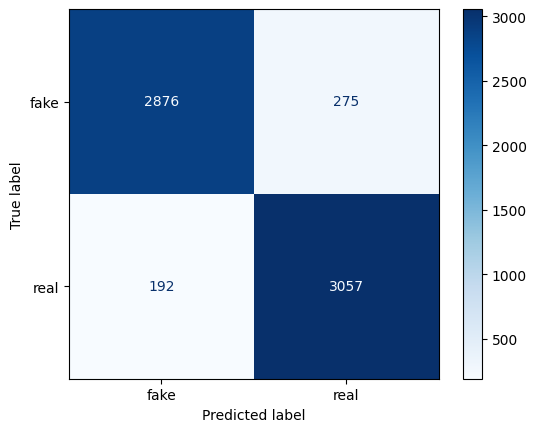

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = (preds > 0.5).astype(int).flatten()
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.show()

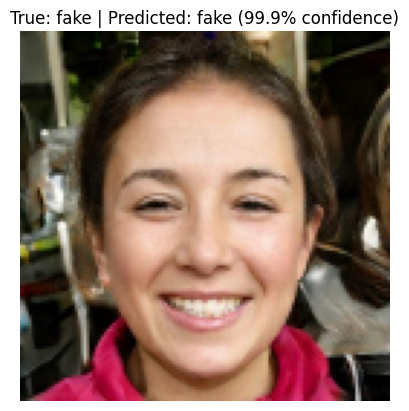

In [ ]:
import matplotlib.pyplot as plt

# Grabbing one batch from the test set
for images, labels in test_ds.take(1):
    img = images[0]
    true_label = labels[0].numpy()
    break

# Predict
pred_prob = model.predict(tf.expand_dims(img, 0), verbose=0)[0][0]  # P(real)
pred_label = 1 if pred_prob > 0.5 else 0
confidence = pred_prob if pred_label == 1 else 1 - pred_prob  # confidence in the PREDICTED class

plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")
plt.title(f"True: {class_names[true_label]} | Predicted: {class_names[pred_label]} ({confidence*100:.1f}% confidence)")
plt.show()